**A Machine Learning Approach for Mobile Money Loan Limit Prediction**

The project aims to develop a Mobile Money Credit Scoring System that analyzes a user’s past mobile money transaction history to determine the amount of money they are eligible to borrow, such as 2000 UGX. The system will first use clustering, an unsupervised machine learning technique, to group users into categories such as low-risk, medium-risk, and high-risk based on their transaction behavior, including transaction frequency, average transaction amount, account activity, and cash flow patterns. After grouping users, a predictive machine learning model using regression will estimate the exact loan amount a user qualifies for based on their historical financial behavior. To achieve this, transaction datasets from sources such as Kaggle will be collected and analyzed using tools like Pandas, Matplotlib, and Seaborn to extract important features including total transactions, average transaction value, monthly transaction volume, transaction consistency, and account age. The final system will include a user interface where a user’s name can be entered, and the system will automatically retrieve the user’s transaction history, analyze it, and display the eligible borrowing amount.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("assignment_dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


<span style="color:blue">Exploratory Data Analysis (EDA)</span>


**Univariate** analysis studies one variable at a time to understand its characteristics and distribution.

Histograms: Show how data values are distributed.

Box plots: Help detect outliers and show data spread.

Bar charts: Used for categorical variables

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df = df.drop('isFraud', axis=1)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [7]:
df = df.drop('isFlaggedFraud', axis=1)
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63


In [8]:
df.duplicated("nameOrig").sum()

np.int64(9313)

In [9]:
#values that appear more than one
counts = df['nameOrig'].value_counts()

print(counts[counts > 1])

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
              ..
C1778059576    2
C2049238175    2
C1624916276    2
C1139137575    2
C591135740     2
Name: count, Length: 9298, dtype: int64


In [10]:
#unique nameOrig entries in the entire DataFrame.
df.nameOrig.value_counts()

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
              ..
C98968405      1
C720209255     1
C1567523029    1
C644777639     1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

In [11]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


In [12]:
# visualizing feature distributions
import matplotlib.pyplot as plt
import seaborn as sns


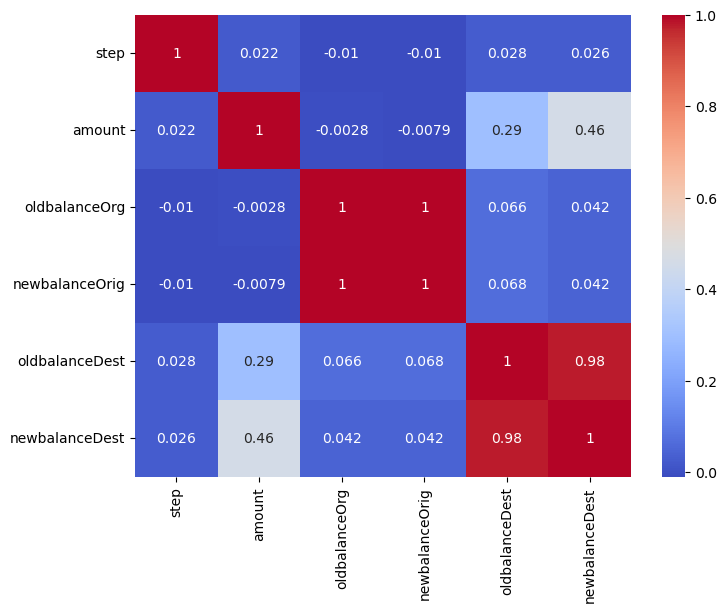

In [13]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

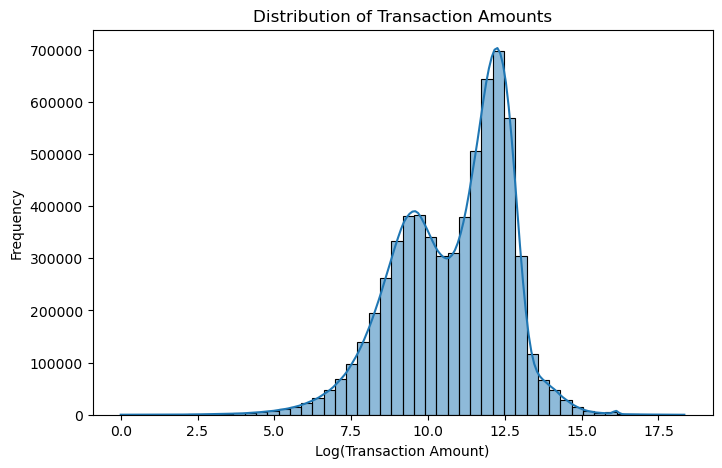

In [14]:
import seaborn as sns
import numpy as np 

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['amount']), bins=50, kde=True)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Log(Transaction Amount)")
plt.ylabel("Frequency")

plt.show()

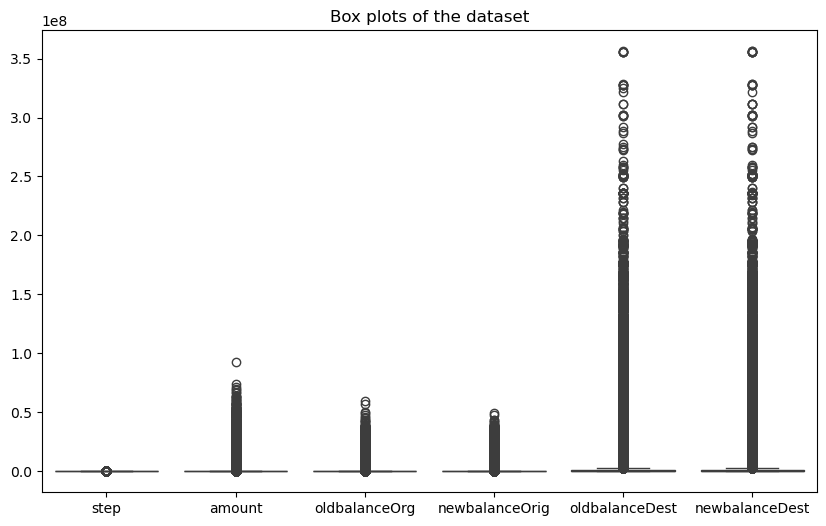

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



# Plotting
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns=['nameOrig','nameDest']))
plt.title("Box plots of the dataset")
plt.show()

<span style="color:blue">Since credit scoring is based on a user's behavior over time, counting how many times each nameOrig (the sender) appears in the dataset is a direct measure of their activity and consistency.</span>

In [16]:
import pandas as pd

# 1. Calculate the frequency of transactions for each user
# We group by the originator name and count the number of 'steps' or entries
user_frequencies = df.groupby('nameOrig')['step'].count().reset_index()
user_frequencies.columns = ['nameOrig', 'transaction_count']

# 2. Merge this feature back into the main dataframe
# This allows the model to see the "consistency" of the user for every transaction row
df = df.merge(user_frequencies, on='nameOrig', how='left')

# 3. Optional: Create a "Consistency Score" 
# For example, transactions per unit of time (step)
# Higher frequency relative to the account age (max step) indicates high activity
user_age = df.groupby('nameOrig')['step'].max().reset_index()
user_age.columns = ['nameOrig', 'account_age_steps']
df = df.merge(user_age, on='nameOrig', how='left')

df['consistency_index'] = df['transaction_count'] / (df['account_age_steps'] + 1)

# Inspect the new features
print(df[['nameOrig', 'transaction_count', 'consistency_index']].head())

      nameOrig  transaction_count  consistency_index
0  C1231006815                  1                0.5
1  C1666544295                  1                0.5
2  C1305486145                  1                0.5
3   C840083671                  1                0.5
4  C2048537720                  1                0.5


<span style="color:blue">To implement the **Cash Flow Ratio**, you are creating a feature that measures the magnitude of a transaction relative to the user's available liquidity at that moment. In credit scoring, this helps identify whether a user is making a typical transaction or one that significantly depletes their account. This is a "Domain-Specific Feature". It tells the model if the user is "living within their means." A ratio consistently close to 1.0 (meaning they spend 100% of their balance) might indicate a higher risk of default. While raw amount and oldbalanceOrg vary wildly between users, the ratio provides a standardized metric that can be compared across all users regardless of whether they are "high-value" or "low-value" customers.</span>

In [17]:
import numpy as np

# 1. Calculate the Cash Flow Ratio
# We add 1 to the denominator to avoid 'Division by Zero' errors for users with 0 balance
df['cash_flow_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# 2. Refined approach: Handling zero balances using a conditional 
# This sets the ratio to 0 if the original balance was 0, otherwise performs the division
df['cash_flow_ratio'] = np.where(
    df['oldbalanceOrg'] > 0, 
    df['amount'] / df['oldbalanceOrg'], 
    0
)

# 3. Optional: Applying a Log Transformation
# Since transaction amounts and ratios can have extreme outliers (as seen in your box plots),
# a log transformation can help normalize the distribution for the model.
df['log_cash_flow_ratio'] = np.log1p(df['cash_flow_ratio'])

# Inspect the results
print(df[['amount', 'oldbalanceOrg', 'cash_flow_ratio', 'log_cash_flow_ratio']].head())

     amount  oldbalanceOrg  cash_flow_ratio  log_cash_flow_ratio
0   9839.64       170136.0         0.057834             0.056223
1   1864.28        21249.0         0.087735             0.084098
2    181.00          181.0         1.000000             0.693147
3    181.00          181.0         1.000000             0.693147
4  11668.14        41554.0         0.280795             0.247481


In [19]:
# 1. Define Eligibility based on a combination of rules (Ground Truth)
# Example Rule: A user is eligible ONLY if:
# - They have more than 5 transactions (Consistency)
# - Their average Cash Flow Ratio is less than 0.8 (Not overspending)
# - They belong to the 'Low Risk' or 'Medium Risk' clusters

# First, let's aggregate these values per user
user_stats = df.groupby('nameOrig').agg({
    'transaction_count': 'max',
    'cash_flow_ratio': 'mean',
    'cluster': 'first'
}).reset_index()

# 2. Apply the Risk Threshold to create the 'is_eligible' label (Target)
# We assume Cluster 0 and 2 are 'safe' and Cluster 1 is 'high risk' 
# based on your previous cluster profile analysis.
user_stats['is_eligible'] = (
    (user_stats['transaction_count'] > 5) & 
    (user_stats['cash_flow_ratio'] <= 0.8) &
    (user_stats['cluster'] != 1)
).astype(int)

# 3. Merge this label back to the main dataframe for training
df = df.merge(user_stats[['nameOrig', 'is_eligible']], on='nameOrig', how='left')

# Check the distribution of your new target
print(df['is_eligible'].value_counts(normalize=True))

KeyError: 'cluster'

In [20]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'transaction_count',
       'account_age_steps', 'consistency_index', 'cash_flow_ratio',
       'log_cash_flow_ratio'],
      dtype='object')

In [22]:

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,transaction_count,account_age_steps,consistency_index,cash_flow_ratio,log_cash_flow_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,1,1,0.5,0.057834,0.056223
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,1,1,0.5,0.087735,0.084098
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,0.5,1.000000,0.693147
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,0.5,1.000000,0.693147
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,1,1,0.5,0.280795,0.247481


Algorithm Selection:

Decision Tree: A good starting point as it provides interpretable rules (e.g., "If transaction count > 5 and Cash Flow Ratio < 0.8, then Eligible").

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define Features (X) and Target (y)
# Drop non-predictive columns and the target column itself
features = ['amount', 'oldbalanceOrg', 'transaction_count', 'cash_flow_ratio']
X = df[features]
y = df['is_eligible']

# Handle any remaining missing values (e.g., fill with 0 or mean)
X = X.fillna(0) 

# 2. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and Train the Model
dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=42) # max_depth prevents overfitting
dt_classifier.fit(X_train, y_train)

# 4. Make Predictions
y_pred = dt_classifier.predict(X_test)

KeyError: 'is_eligible'

Filter Data: Train the regression model only on the users who are eligible (is_eligible == 1).

Define the Target (Loan Limit): Similar to eligibility, you need a ground-truth rule for the loan limit. For this project, you can simulate a rule based on their financial capacity.

Example Rule: The initial loan limit is 10% of their average monthly transaction volume or their average oldbalanceOrg, whichever is lower, capped at a maximum value (e.g., 2000 UGX as per your prompt).

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Filter for Eligible Users Only
eligible_df = df[df['is_eligible'] == 1].copy()

# 2. Simulate the Loan Limit Target (Ground Truth Rule)
# Let's say the limit is 10% of their average transaction amount, capped at 2000
eligible_df['simulated_loan_limit'] = (eligible_df['amount'] * 0.10).clip(upper=2000)

X_reg = eligible_df[features]
y_reg = eligible_df['simulated_loan_limit']

# Handle NaNs
X_reg = X_reg.fillna(0)

# 3. Split the Data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# 4. Initialize and Train the Regression Model
# Using Ridge to handle potential multicollinearity between financial features
ridge_regressor = Ridge(alpha=1.0) 
ridge_regressor.fit(X_train_reg, y_train_reg)

# 5. Make Predictions
y_pred_reg = ridge_regressor.predict(X_test_reg)

Classification Evaluation:

Confusion Matrix: Shows True Positives, False Positives, etc.

Precision: Out of all users predicted as eligible, how many actually were? (Crucial to minimize bad loans).

Recall: Out of all truly eligible users, how many did the model find?

In [1]:
# Evaluate Classification Model
print("--- Classification Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Eligibility Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Classification Metrics ---


NameError: name 'accuracy_score' is not defined

Mean Absolute Error (MAE): The average absolute difference between the predicted loan limit and the calculated rule.

Root Mean Squared Error (RMSE): Penalizes larger errors more heavily.

In [ ]:
# Evaluate Regression Model
print("\n--- Regression Metrics ---")
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"RMSE: {rmse:.2f} UGX")
print(f"MAE: {mae:.2f} UGX")

<span style="color:blue">This indicates that while most users perform relatively small transactions and maintain low balances, a smaller group of users performs extremely large transactions or holds very high account balances</span>

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select features
X = df[['amount','oldbalanceOrg','newbalanceOrig',
        'oldbalanceDest','newbalanceDest']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# PCA reduction
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=clusters,
    cmap='viridis'
)

# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.title("PCA Visualization of Mobile Money User Clusters")

plt.show()

In [ ]:
import pandas as pd

# Add cluster labels to your dataframe
df['cluster'] = clusters

# Get mean see the issues in your cell. Here's the corrected code:


import pandas as pd

# Add cluster labels to your dataframe
df['cluster'] = clusters

# Get mean values per cluster
cluster_profiles = df.groupby('cluster')[['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                                           'oldbalanceDest', 'newbalanceDest']].mean()
print(cluster_profiles)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# STEP 1: Select Feature
# We use only transaction amount
X = df[['amount']]

# STEP 2: Scale the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 3: Apply KMeans Clustering
# Create 3 transaction groups
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['cluster'] = clusters

# STEP 4: Reduce Dimensions using PCA
# Since we only have one feature,
# PCA will also produce one component
pca = PCA(n_components=1)

pca_result = pca.fit_transform(X_scaled)

# STEP 5: Visualization

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    pca_result[:,0],
    df['amount'],
    c=clusters,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Transaction Amount")
plt.title("KMeans Clustering of Transaction Amount Patterns")

plt.colorbar(scatter, label='Cluster')

plt.show()

# STEP 6: Analyze Cluster Patterns

print("\n===== Cluster Summary =====\n")

cluster_summary = df.groupby('cluster')['amount'].agg([
    'count',
    'mean',
    'std',
    'min',
    'max'
])

print(cluster_summary)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)
# Features
X = df[['amount']]

# Labels (clusters created earlier)
y = df['cluster']

from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=2, random_state=0)
dtree.fit(X_train, y_train)
dtree_preds = dtree.predict(X_test)
dtree_acc = accuracy_score(y_test, dtree_preds)
dtree_cm = confusion_matrix(y_test, dtree_preds)

print("Decision Tree Accuracy:", dtree_acc)

plt.figure(figsize=(4, 3))
sns.heatmap(dtree_cm, annot=True, cmap="Blues", fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
plt.scatter(df.nameOrig,df.amount,marker='+',color='red')
plt.show()

In [ ]:
print(df)

In [ ]:
import numpy as np

# 1. Calculate the Cash Flow Ratio
# We add 1 to the denominator to avoid 'Division by Zero' errors for users with 0 balance
df['cash_flow_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# 2. Refined approach: Handling zero balances using a conditional 
# This sets the ratio to 0 if the original balance was 0, otherwise performs the division
df['cash_flow_ratio'] = np.where(
    df['oldbalanceOrg'] > 0, 
    df['amount'] / df['oldbalanceOrg'], 
    0
)

# 3. Optional: Applying a Log Transformation
# Since transaction amounts and ratios can have extreme outliers (as seen in your box plots),
# a log transformation can help normalize the distribution for the model.
df['log_cash_flow_ratio'] = np.log1p(df['cash_flow_ratio'])

# Inspect the results
print(df[['amount', 'oldbalanceOrg', 'cash_flow_ratio', 'log_cash_flow_ratio']].head())